#### Exercise 4

Hugo Lladró Prats, Inés Mang Román, Ahmet Meriç Kızıltaş


As usual we will use pandas and seaborn for the creation of graphics. We begin by installing the libraries.

In [1]:
!mamba install pandas
!mamba install seaborn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.40079999999701976 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.1                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge, conda-forge

Solving enviro

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp

a) The file values.txt that is available on eCampus contains 40 scalar values. Use the seaborn
library with default parameters to visualize the distribution of those values using Kernel Density Estimation. Based on the visualization, at which location(s) do you think the underlying
distribution has a mode (peak)? (2P)

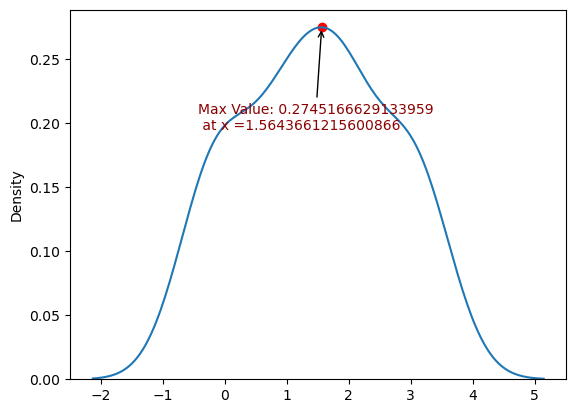

In [19]:
data = pd.read_csv('values.txt', sep=" ", header=None)

plot = sns.kdeplot(data=data, legend = False)
x, y = plot.lines[0].get_data()
plt.scatter(x[np.argmax(y)], y.max(), color = 'r', label = 'maximum')
plt.annotate(f'Max Value: {y.max()}\n at x ={x[np.argmax(y)]}', 
             xy=(x[np.argmax(y)], y.max()), 
             xytext=(x[np.argmax(y)]-2, y.max()-0.08),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='darkred')
plt.show()

Based on the figure, we observe that the plot seems to attain its maximum at x = 1.56, at 0.27. The distribution is unimodal and roughly normal; the area around the mode shows a peak, while the value quickly drops outside of [0, 3].

b) Produce alternative KDE plots by adjusting the bandwidth to higher and lower values. Briefly
describe in your own words how this changes the shape of the estimated distribution. Visualize
the same data in a different way to help you decide which setting most faithfully reflects the
distribution which generated the data. In particular, at which location(s) would you assume it
has modes? (3P)

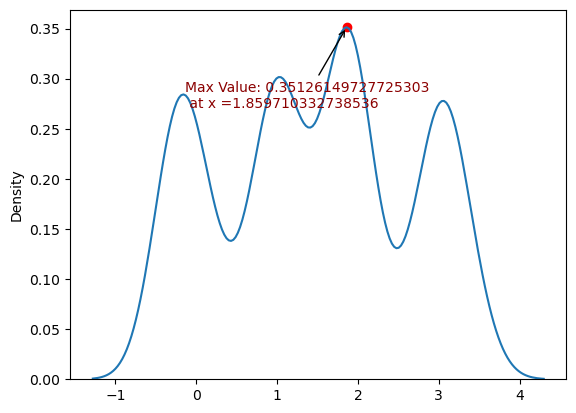

In [20]:
plot = sns.kdeplot(data=data, legend = False, bw_adjust = 0.5)
x, y = plot.lines[0].get_data()
plt.scatter(x[np.argmax(y)], y.max(), color = 'r', label = 'maximum')
plt.annotate(f'Max Value: {y.max()}\n at x ={x[np.argmax(y)]}', 
             xy=(x[np.argmax(y)], y.max()), 
             xytext=(x[np.argmax(y)]-2, y.max()-0.08),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='darkred')
plt.show()

If we use half the standard bandwidth, we now see that the distribution has several peaks, while the mode is at x = 1.85.The shape is also qualitatively different, no longer unimodal, and with no semblance of normality.

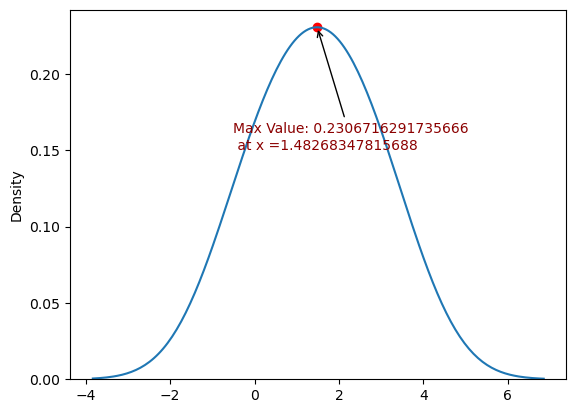

In [22]:
plot = sns.kdeplot(data=data, legend = False, bw_adjust = 2)
x, y = plot.lines[0].get_data()
plt.scatter(x[np.argmax(y)], y.max(), color = 'r', label = 'maximum')
plt.annotate(f'Max Value: {y.max()}\n at x ={x[np.argmax(y)]}', 
             xy=(x[np.argmax(y)], y.max()), 
             xytext=(x[np.argmax(y)]-2, y.max()-0.08),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='darkred')
plt.show()

If we use double the standard bandwidth, the distribution now looks almost like a normal distribution centered at the mode x = 1.48. We cannot observe the detail of the individual observations.

Now we will use a strip plot to observe the actual observations and try to detect the underlying pattern.

<Axes: >

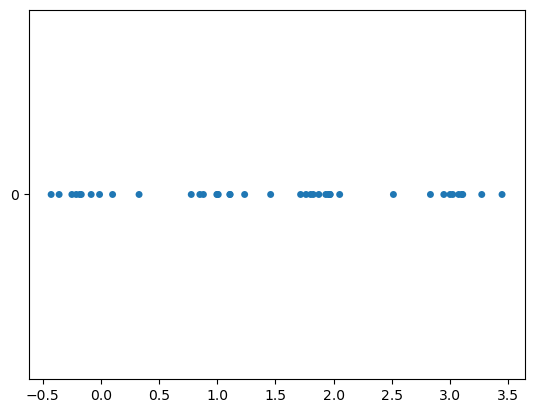

In [28]:
sns.stripplot(data=data, orient = 'h', jitter =False)

In this visualization we observe that  there are roughly 4 clusters of data, centered at x = -0.25, 1, 1.75 and 3 respectively. The greatest concentration of observations sits around x = 1.75 so the mode should be there. 